<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/01_Assignment_Logistic_Regression_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Instructions
* For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
* Please ensure that you are not simply copying each other's code but rather striving to understand and learn from the work.
* Provide the R code at the end of your solution and include R commands along with R outputs to clearly describe your solutions.

### Dataset Overview
* The dataset contains information about medical diagnostic measurements for predicting diabetes in Pima Indian women. The outcome variable is `Outcome`, where:
* 1 indicates diabetes-positive.
* 0 indicates diabetes-negative.

**The dataset includes the following variables:**

* `Pregnancies`: Number of pregnancies.
* `Glucose`: Plasma glucose concentration.
* `BloodPressure`: Diastolic blood pressure (mm Hg).
* `SkinThickness`: Triceps skinfold thickness (mm).
* `Insulin`: 2-Hour serum insulin (mu U/ml).
* `BMI`: Body mass index (weight in kg/(height in m)^2).
* `DiabetesPedigreeFunction`: Diabetes pedigree function (genetic risk).
* `Age`: Age (years).
* `Outcome`: Binary outcome (0 or 1).

`Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.`

## Questions

### Q0: Install necessary packages
Install and load the following packages:
`tidyverse`
`dplyr`
`ggplot2`

In [5]:
# Install packages
install.packages("tidyverse")
install.packages("dplyr")
install.packages("ggplot2")

# Load packages
library(tidyverse)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### Q1: Load the dataset
* Read the Pima Indians Diabetes Database into R.  
Points: 2

Answer here

In [14]:
list.files(path = "/content", recursive = TRUE)

[1] "sample_data/anscombe.json"               
[2] "sample_data/california_housing_test.csv" 
[3] "sample_data/california_housing_train.csv"
[4] "sample_data/diabetes.csv"                
[5] "sample_data/mnist_test.csv"              
[6] "sample_data/mnist_train_small.csv"       
[7] "sample_data/README.md"

In [16]:
df <- read.csv("/content/diabetes.csv")

In [18]:
# check that upload worked
head(df)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


### Q2: Explore the dataset
1. How many rows and columns are in the dataset?
2. How many columns are categorical, and how many are continuous?
Points: 3

### Q3: Create a random subset
Create a random subset of 500 rows from the dataset using the following code:

In [19]:
# Q2
#Load the dataset
df <- read.csv("diabetes.csv")

# 1. Rows and columns
dim(df)        # shows rows x columns
nrow(df)       # rows only
ncol(df)       # columns only

# 2. Column types
str(df)

#Q3
# Set a seed so your results are reproducible
set.seed(123)

# Create the random subset
model_data <- df[sample(nrow(df), 500), ]

[1] 768   9

[1] 768

[1] 9

'data.frame':	768 obs. of  9 variables:
 $ Pregnancies             : int  6 1 8 1 0 5 3 10 2 8 ...
 $ Glucose                 : int  148 85 183 89 137 116 78 115 197 125 ...
 $ BloodPressure           : int  72 66 64 66 40 74 50 0 70 96 ...
 $ SkinThickness           : int  35 29 0 23 35 0 32 0 45 0 ...
 $ Insulin                 : int  0 0 0 94 168 0 88 0 543 0 ...
 $ BMI                     : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ DiabetesPedigreeFunction: num  0.627 0.351 0.672 0.167 2.288 ...
 $ Age                     : int  50 31 32 21 33 30 26 29 53 54 ...
 $ Outcome                 : int  1 0 1 0 1 0 1 0 1 1 ...


Use this subset (`model_data`) for all subsequent questions.  
Points: 1

### Q4: Tabulate and visualize the outcome variable
1. Tabulate and plot the distribution of the outcome variable (Outcome).  
2. Save this plot as a PDF file (4 inches wide, 3 inches tall) and submit it along with your assignment.
Points: 3




  0   1 
322 178 

agg_record_3533094137e 
                     2

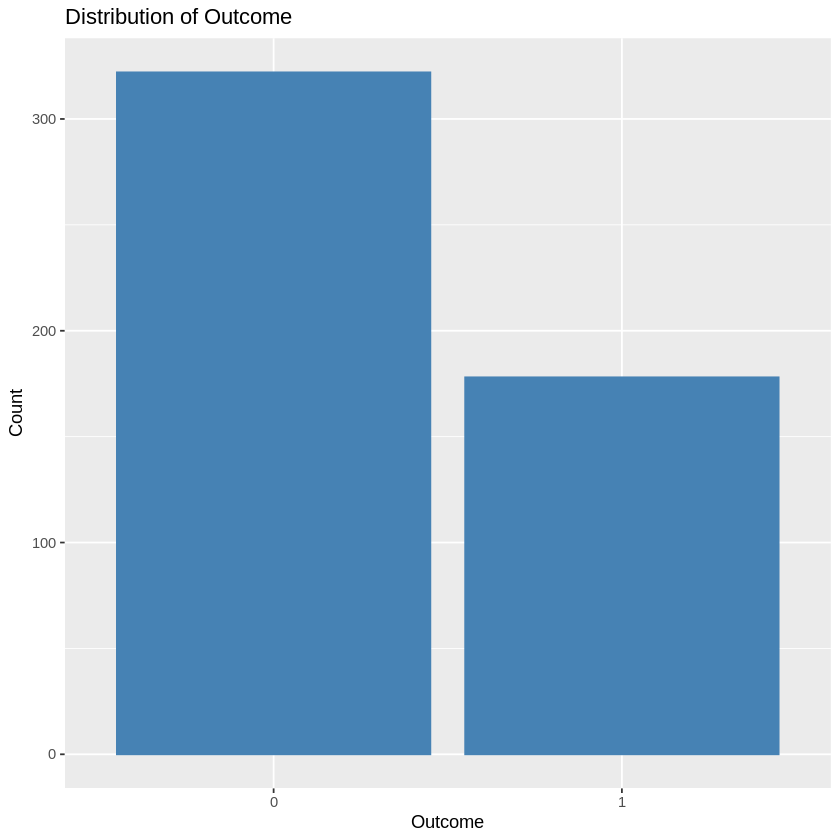

In [20]:
#tabulating the outcome variable
table(model_data$Outcome)

#plotting distribution
p <- ggplot(model_data, aes(x = factor(Outcome))) +
  geom_bar(color = 'steelblue', fill = 'steelblue') +
  xlab('Outcome') + ylab('Count') +
  labs(title = "Distribution of Outcome")
p

#save as PDF
pdf("outcome_plot.pdf", width = 4, height = 3)
p
dev.off()

### Q5: Explore covariates
1. Choose five covariates that you think might affect diabetes prediction based on general understanding.
2. For each covariate, create a table showing the distribution of values for each outcome (0 or 1).
3. Generate bar plots for these covariates using facet_grid in ggplot2.
Points: 5



In [21]:
#choosing 5 covariates that might affect diabetes

#table for each covariate showing distribution of values
# Convert Outcome to factor so it reads as categories
model_data$Outcome <- factor(model_data$Outcome)

# Tables showing distribution by outcome
table(model_data$Outcome, cut(model_data$Glucose, breaks=5))
table(model_data$Outcome, cut(model_data$BMI, breaks=5))
table(model_data$Outcome, cut(model_data$Age, breaks=5))
table(model_data$Outcome, cut(model_data$BloodPressure, breaks=5))
table(model_data$Outcome, cut(model_data$Pregnancies, breaks=5))

   
    (-0.199,39.8] (39.8,79.6] (79.6,119] (119,159] (159,199]
  0             2          21        188       100        11
  1             2           0         41        79        56

   
    (-0.0671,13.4] (13.4,26.8] (26.8,40.3] (40.3,53.7] (53.7,67.2]
  0              5          99         193          24           1
  1              2           8         133          33           2

   
    (20.9,33] (33,45] (45,57] (57,69] (69,81.1]
  0       227      59      21      14         1
  1        85      55      25      12         1

   
    (-0.11,22] (22,44] (44,66] (66,88] (88,110]
  0         13       5     114     172       18
  1         11       1      37     108       21

   
    (-0.017,3.4] (3.4,6.8] (6.8,10.2] (10.2,13.6] (13.6,17]
  0          203        74         34          11         0
  1           75        44         47           8         4

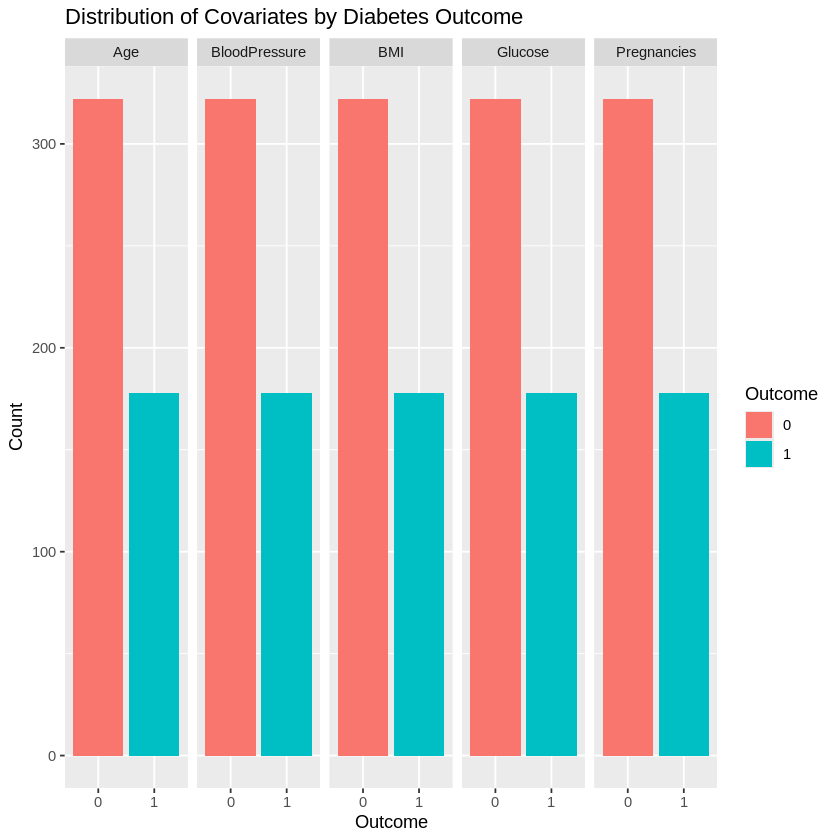

In [22]:
#bar plots for covariates
library(ggplot2)
library(tidyr)

#reshape data for plotting
plot_data <- pivot_longer(model_data,
                          cols = c(Glucose, BMI, Age, BloodPressure, Pregnancies),
                          names_to = "Covariate",
                          values_to = "Value")

#bar plot with facet_grid
ggplot(plot_data, aes(x = Outcome, fill = Outcome)) +
  geom_bar() +
  facet_grid(~ Covariate) + #split into separate panels, one for each coviariate
  xlab("Outcome") + ylab("Count") + #label axes and add title
  labs(title = "Distribution of Covariates by Diabetes Outcome")

## Q6: Understanding the problem
1. What is the outcome variable in this dataset?
2. Is the outcome continuous, count, or binary?
3. Based on this, which type of GLM family is appropriate?

In [ ]:
#Answer 1: 0 or 1, or diabetes or no diabetes
#Answer 2: Binary
#Answer 3: Binomial

## Q7 Writing the model
1. Write the mathematical form of the model:
2. What is being modeled on the left-hand side?
3. What transformation is applied (logit)?
4. How would you express (logit) this in words?

ANSWERS:

1) logit(p) = β₀ + β₁X₁ + β₂X₂ + β₃X₃ + β₄X₄ + β₅X₅
2) On the left side, probabilty of having diabetes (the outcome 0 or 1)
3) logit
4) Logit is odds of the probability of having diabetes dividied by the probability of not having diabetes, and then taking the odds and transforming the probability to have no limits, rather than be bound bewteen 0 and 1.


### Q7: Run univariate logistic regression models
1. Perform univariate logistic regression for each of the five selected covariates using the `glm()` function with a binomial family.
2. Identify which variable has the highest beta coefficient and explain its significance.
Points: 10



In [23]:
#run univariate models for each covariate
model_Glucose <- glm(Outcome ~ Glucose, data = model_data, family = "binomial")
model_BMI <- glm(Outcome ~ BMI, data = model_data, family = "binomial")
model_Age <- glm(Outcome ~ Age, data = model_data, family = "binomial")
model_BloodPressure <- glm(Outcome ~ BloodPressure, data = model_data, family = "binomial")
model_Pregnancies <- glm(Outcome ~ Pregnancies, data = model_data, family = "binomial")

summary(model_Glucose)
summary(model_BMI)
summary(model_Age)
summary(model_BloodPressure)
summary(model_Pregnancies)


Call:
glm(formula = Outcome ~ Glucose, family = "binomial", data = model_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -5.458299   0.534501  -10.21   <2e-16 ***
Glucose      0.038691   0.004107    9.42   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 527.29  on 498  degrees of freedom
AIC: 531.29

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ BMI, family = "binomial", data = model_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.63118    0.50357  -7.211 5.56e-13 ***
BMI          0.09250    0.01482   6.241 4.36e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 603.74  on 498  degrees of freedom
AIC: 607.74

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ Age, family = "binomial", data = model_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.008000   0.296236  -6.778 1.22e-11 ***
Age          0.041934   0.008224   5.099 3.41e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 623.69  on 498  degrees of freedom
AIC: 627.69

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ BloodPressure, family = "binomial", data = model_data)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)   
(Intercept)   -1.209679   0.371143  -3.259  0.00112 **
BloodPressure  0.008920   0.005149   1.732  0.08322 . 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 647.91  on 498  degrees of freedom
AIC: 651.91

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ Pregnancies, family = "binomial", data = model_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.07768    0.14884  -7.240 4.47e-13 ***
Pregnancies  0.12216    0.02798   4.365 1.27e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 631.40  on 498  degrees of freedom
AIC: 635.4

Number of Fisher Scoring iterations: 4


In [ ]:
#pregnany has the highest beta coefficient at 0.122.
#This is significant because for eavery pregnancy, the log odds of having diabetes increases by 0.122.
#pregnancy has the highest beta, but it may not be the most important predictors when taking AIC under consideration.

### Q8: Interpret odds ratios
1. For each covariate in your final model:
2. Calculate odds ratios manually from model coefficients.
3. Interpret these odds ratios in words, considering whether they are statistically significant.
4. Use `sjPlot::tab_model()` to verify your calculations and compare results.
Points: 10



In [24]:
#calculate ORs for each covariate; exponentiating beta coefficinets
exp(coef(model_Glucose))
exp(coef(model_BMI))
exp(coef(model_Age))
exp(coef(model_BloodPressure))
exp(coef(model_Pregnancies))

(Intercept)     Glucose 
0.004260795 1.039449054

(Intercept)         BMI 
 0.02648498  1.09691743

(Intercept)         Age 
  0.1342569   1.0428252

(Intercept) BloodPressure 
     0.298293      1.008960

(Intercept) Pregnancies 
  0.3403851   1.1299302

3. ANSWERS:

- Glucose: for every 1 unit increase in glucose, the odds of having diabetes increases by 1.039 times.

- BMI: for every one unit increase in BMI, the odds of having diabetes increases by 1.097 times.
- Age: for every one year increase in age, the odds of having diabetes increases by 1.043 times.
- BP: for every one unit increase in BP, the odds of having diabetes increases by 1.009.
- Pregnancy: for every one additional pregnancy, the odds of having diabetes increases by 1.129 times.

### Q9: Model diagnostics (do not attempt, for next assingment)
1. How many properties can you access from a fitted logistic regression model object in R? Use names(YOURMODEL) to explore.
2. Discuss any two properties that provide insights into model performance or interpretation.
3. What is deviance for your model?
4. What does a large reduction in deviance indicate?
5. How does deviance relate to:  
  model fit?  
  likelihood?  
Points: 10



## Q10 : Perform Residual diagnostics (do not attempt, for next assingment)
1. What types of residuals are available in GLMs?
2. Why do residual plots look different for binary outcomes?
3. Why do we see two bands in residual plots?
4. Which residual is generally preferred for GLMs and why?

## Q11: Run analysis for Influential observations using Cook's distance calculations (do not attempt, for next assingment))
1. What is Cook’s Distance measuring?
2. What does a large Cook’s Distance imply?
3. Should influential points always be removed? Why or why not?

## Q12: Run Model calibration for your model and data (do not attempt, for next assingment))
1. What does calibration mean in logistic regression?

### Q13: Final interpretation
Based on your analysis:
1. Which variable has the highest odds ratio for predicting diabetes?
2. Write down statistical interpretation of this odds ratio.  
Points: 10

## Bonus Question:
Manully code IRLS method to fit your logistic regression and compare the results with results from `glm()` function